# NFL Draft Data Acquisition — Pro-Football-Reference (2000–2020)

Scrape draft tables from PFR for years 2000–2020, clean the data, compute wAVOE, and cache to CSV.

In [ ]:
# Install dependencies (run once)
# !pip install requests beautifulsoup4 pandas lxml

In [ ]:
# dont run this without changing the directory
from google.colab import drive
drive.mount('/content/drive')

%cd '/content/drive/MyDrive/SportDataChallenge26/2000-2020 SDC'

Mounted at /content/drive
/content/drive/MyDrive/SportDataChallenge26/2000-2020 SDC


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager as fm, rcParams
import time
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [ ]:
MERGED_FILE = 'nfl_combine_2000_2020.csv'
YEARS = range(2000, 2021)  # 2000 to 2020 inclusive (21 years)

In [ ]:
# Load from cache if available; otherwise scrape all years
if os.path.exists(MERGED_FILE):
    df = pd.read_csv(MERGED_FILE)
    print(f"Loaded cached data: {len(df)} rows from {MERGED_FILE}")
else:
  frames = []
  success_count = 0
  for year in YEARS:
      # Excel files should be named exactly: SDC 2000.xlsx, SDC 2001.xlsx, ...
      file_name = f"SDC {year}.xlsx"
      if not os.path.exists(file_name):
          print(f"Warning: File not found for {year}: {file_name}")
          continue
      try:
          year_df = pd.read_excel(file_name)
          # Ensure Season column exists
          if "Season" not in year_df.columns:
              year_df["Season"] = year
          frames.append(year_df)
          success_count += 1
      except Exception as e:
          print(f"Warning: Failed to read {file_name}: {e}")
          continue
  df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
  print(f"Build complete: {success_count} years succeeded, {len(df)} total rows")

Loaded cached data: 5350 rows from nfl_combine_2000_2020.csv


In [ ]:
# Data cleaning (always apply after loading/scraping)

# ── Step 1: Detect and fix corrupted headers ─────────────────────────────────
# The cached CSV was saved with the first data row promoted to headers.
# We detect this by checking if 'Rnd' is missing AND a numeric-looking value
# is in the first column position (e.g. '1' instead of 'Rnd').
PFR_COLS = [
    'Rnd', 'Pick', 'Tm', 'Player', 'Pos', 'Age', 'To', 'AP1', 'PB', 'St',
    'wAV', 'DrAV', 'G',
    'Cmp', 'Pass_Att', 'Pass_Yds', 'Pass_TD', 'Pass_Int',
    'Rush_Att', 'Rush_Yds', 'Rush_TD',
    'Rec', 'Rec_Yds', 'Rec_TD',
    'Solo', 'Def_Int', 'Sk',
    'College/Univ', 'Misc', 'pfref_id', 'Season', 'wAVOE'
]

if 'Rnd' not in df.columns:
    if any('Unnamed:' in str(col) for col in df.columns) and not df.empty:
        # The corrupted header row IS a data row — rescue it before overwriting
        rescued_row = pd.DataFrame([list(df.columns)], columns=range(len(df.columns)))
        df.columns = range(len(df.columns))  # temporarily make numeric
        df = pd.concat([rescued_row, df], ignore_index=True)

    n_cols = len(df.columns)
    if n_cols == len(PFR_COLS):
        df.columns = PFR_COLS
    elif n_cols < len(PFR_COLS):
        df.columns = PFR_COLS[:n_cols]
    else:
        df.columns = PFR_COLS + [f'Extra_{i}' for i in range(n_cols - len(PFR_COLS))]

    import os
    if os.path.exists(MERGED_FILE):
        os.remove(MERGED_FILE)
        print(f"Deleted corrupted cache: {MERGED_FILE}")

# ── Step 2: Strip whitespace from column names ───────────────────────────────
df.columns = [str(c).strip() for c in df.columns]

# ── Step 3: Flatten MultiIndex columns if present ────────────────────────────
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]

# ── Step 4: Drop duplicate PFR header rows (section dividers) ────────────────
if 'Rnd' in df.columns:
    df = df.loc[df['Rnd'] != 'Rnd'].copy()

# ── Step 5: Convert numeric columns ──────────────────────────────────────────
numeric_cols = ['Rnd', 'Pick', 'Age', 'To', 'AP1', 'PB', 'St', 'wAV', 'DrAV', 'G',
                'Wt', '40yd', 'Vertical', 'Broad Jump', 'Cone', 'Shuttle', 'Season']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Handle "Broad Jump" vs "BroadJump"
if 'Broad Jump' in df.columns and 'BroadJump' not in df.columns:
    df['BroadJump'] = df['Broad Jump']

# ── Step 6: Drop undrafted / no pick number ───────────────────────────────────
if 'Pick' in df.columns:
    df = df.dropna(subset=['Pick']).copy()

# ── Step 7: Restrict to 2000–2020 ────────────────────────────────────────────
if 'Season' in df.columns:
    df = df.loc[df['Season'] <= 2020].copy()

# ── Step 8: Compute wAVOE ────────────────────────────────────────────────────
if 'Pick' in df.columns and 'wAV' in df.columns:
    mean_wav_by_pick = df.groupby('Pick')['wAV'].transform('mean')
    df['wAVOE'] = df['wAV'] - mean_wav_by_pick

# ── Sanity check ─────────────────────────────────────────────────────────────
assert 'Rnd' in df.columns and 'Player' in df.columns, \
    f"Critical columns still missing! Found: {df.columns.tolist()}"

print(f"Shape: {df.shape}")
print(df[['Rnd', 'Pick', 'Player', 'Pos', 'wAV', 'wAVOE']].head())

# ── Save corrected file ───────────────────────────────────────────────────────
df.to_csv(MERGED_FILE, index=False)
print(f"Saved cleaned data to {MERGED_FILE} ({len(df)} rows)")

Shape: (5350, 32)
   Rnd  Pick           Player Pos   wAV      wAVOE
0  1.0   1.0   Courtney Brown  DE  27.0 -49.428571
1  1.0   2.0  LaVar Arrington  LB  46.0  -7.476190
2  1.0   3.0    Chris Samuels   T  63.0  10.714286
3  1.0   4.0    Peter Warrick  WR  27.0 -26.904762
4  1.0   5.0      Jamal Lewis  RB  69.0  13.523810
Saved cleaned data to nfl_combine_2000_2020.csv (5350 rows)


In [ ]:
# Summary
print(f"Total rows: {len(df)}")
if "Season" in df.columns:
    print(f"Seasons: {sorted(df['Season'].unique())}")
print(df.head(10))

Total rows: 5350
Seasons: [np.float64(2000.0), np.float64(2001.0), np.float64(2002.0), np.float64(2003.0), np.float64(2004.0), np.float64(2005.0), np.float64(2006.0), np.float64(2007.0), np.float64(2008.0), np.float64(2009.0), np.float64(2010.0), np.float64(2011.0), np.float64(2012.0), np.float64(2013.0), np.float64(2014.0), np.float64(2015.0), np.float64(2016.0), np.float64(2017.0), np.float64(2018.0), np.float64(2019.0), np.float64(2020.0)]
   Rnd  Pick   Tm              Player Pos   Age      To  AP1   PB    St  ...  \
0  1.0   1.0  CLE      Courtney Brown  DE  22.0  2005.0  0.0  0.0   4.0  ...   
1  1.0   2.0  WAS     LaVar Arrington  LB  22.0  2006.0  0.0  3.0   5.0  ...   
2  1.0   3.0  WAS       Chris Samuels   T  23.0  2009.0  0.0  6.0   9.0  ...   
3  1.0   4.0  CIN       Peter Warrick  WR  23.0  2005.0  0.0  0.0   4.0  ...   
4  1.0   5.0  BAL         Jamal Lewis  RB  21.0  2009.0  1.0  1.0   9.0  ...   
5  1.0   6.0  PHI         Corey Simon  DT  23.0  2007.0  0.0  1.0   6.0  

In [ ]:
# Ensure figures directory exists
os.makedirs("figures", exist_ok=True)

# Global plotting style: light academic theme for better visibility on white backgrounds
sns.set_theme(style="whitegrid", context="talk")
rcParams["figure.facecolor"] = "#FFFFFF"
rcParams["axes.facecolor"] = "#FFFFFF"
rcParams["axes.edgecolor"] = "#333333"
rcParams["axes.labelcolor"] = "#000000"
rcParams["xtick.color"] = "#000000"
rcParams["ytick.color"] = "#000000"
rcParams["text.color"] = "#000000"
rcParams["axes.titleweight"] = "bold"
rcParams["font.size"] = 11  # minimum 10pt everywhere

# Ensure wAVOE exists (in case CSV cache predates this field)
if "wAVOE" not in df.columns and {"Pick", "wAV"}.issubset(df.columns):
    mean_wav_by_pick = df.groupby("Pick")["wAV"].transform("mean")
    df["wAVOE"] = df["wAV"] - mean_wav_by_pick

# Position grouping logic
QB_POS = ["QB"]
SKILL_POS = ["WR", "RB", "TE"]
BIG_SKILL_POS = ["FB", "TE"]
LINE_POS = ["T", "G", "C"]
DEFENSE_POS = ["DE", "DT", "LB", "CB", "S", "NT"]


def position_group(pos: str) -> str:
    if not isinstance(pos, str):
        return "Other"
    pos = pos.strip().upper()
    if pos in QB_POS:
        return "QB"
    if pos in SKILL_POS:
        return "Skill"
    if pos in BIG_SKILL_POS:
        return "Big Skill"
    if pos in LINE_POS:
        return "Line"
    if pos in DEFENSE_POS:
        return "Defense"
    return "Other"


if "PosGroup" not in df.columns and "Pos" in df.columns:
    df["PosGroup"] = df["Pos"].apply(position_group)

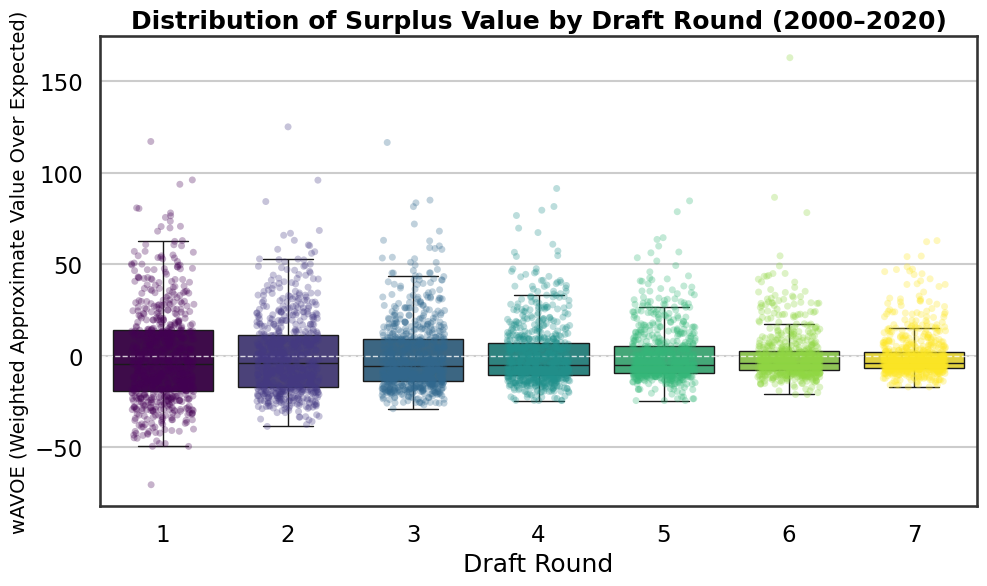

In [ ]:
# 1. wAVOE by Draft Round (Box + Strip plot)
plot_df = df.copy()

# Keep standard draft rounds and non-missing wAVOE
plot_df = plot_df.loc[
    plot_df["Rnd"].notna()
    & plot_df["wAVOE"].notna()
    & (plot_df["Rnd"] >= 1)
    & (plot_df["Rnd"] <= 7)
].copy()

# Ensure integer rounds for clear x-axis ordering
plot_df["Rnd"] = plot_df["Rnd"].astype(int)

fig, ax = plt.subplots(figsize=(10, 6))

# Boxplot by round
sns.boxplot(
    data=plot_df,
    x="Rnd",
    y="wAVOE",
    hue="Rnd", # Add hue to suppress FutureWarning
    palette="viridis",
    ax=ax,
    showfliers=False,
    legend=False # Set legend to False as hue is now Rnd
)

# Stripplot overlay to show individual players
sns.stripplot(
    data=plot_df,
    x="Rnd",
    y="wAVOE",
    hue="Rnd",
    palette="viridis",
    dodge=False,
    jitter=0.25,
    alpha=0.3,
    ax=ax,
    legend=False
)

ax.set_xlabel("Draft Round")
ax.set_ylabel("wAVOE (Weighted Approximate Value Over Expected)", fontsize=14)
ax.set_title("Distribution of Surplus Value by Draft Round (2000–2020)")

# Horizontal reference line at zero surplus value
ax.axhline(0, color="white", linewidth=1, linestyle="--", alpha=0.8)

fig.tight_layout()
fig.savefig("figures/wavoe_by_round.png", dpi=300, bbox_inches="tight")
plt.show()

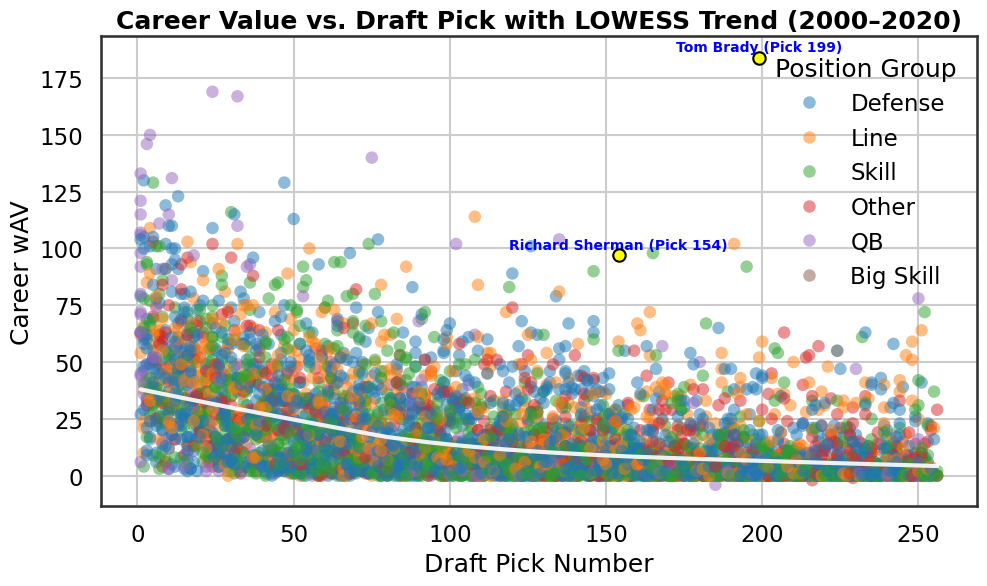

In [ ]:
# 2. wAV vs. Draft Pick (Scatter + LOWESS trendline)

from seaborn.regression import regplot

plot_df = df.copy()

# Require pick, wAV, and position group information
required_cols = ["Pick", "wAV"]
if "PosGroup" in df.columns:
    required_cols.append("PosGroup")

plot_df = plot_df.dropna(subset=[c for c in required_cols if c in plot_df.columns])

# Restrict to typical draft picks
plot_df = plot_df.loc[(plot_df["Pick"] >= 1) & (plot_df["Pick"] <= 256)].copy()

fig, ax = plt.subplots(figsize=(10, 6))

# Scatter colored by position group (or raw position if PosGroup missing)
hue_col = "PosGroup" if "PosGroup" in plot_df.columns else "Pos"

sns.scatterplot(
    data=plot_df,
    x="Pick",
    y="wAV",
    hue=hue_col,
    palette="tab10",
    alpha=0.5,
    edgecolor="none",
    ax=ax,
)

# LOWESS trend line in bold white
try:
    regplot(
        data=plot_df,
        x="Pick",
        y="wAV",
        lowess=True,
        scatter=False,
        line_kws={"color": "white", "linewidth": 3, "alpha": 0.9},
        ax=ax,
    )
except Exception as e:
    # Fall back to a simple rolling mean if LOWESS is unavailable
    sorted_df = plot_df.sort_values("Pick")
    window = max(15, int(len(sorted_df) * 0.05))
    rolling = (
        sorted_df.set_index("Pick")["wAV"]
        .rolling(window=window, min_periods=max(5, window // 3))
        .mean()
    )
    ax.plot(rolling.index, rolling.values, color="white", linewidth=3, alpha=0.9)

# Annotate famous outliers where available
for name in ["Tom Brady", "Richard Sherman"]:
    mask = df["Player"].astype(str).str.contains(name, case=False, na=False)
    if mask.any():
        row = df.loc[mask].sort_values("wAV", ascending=False).iloc[0]
        if not (pd.isna(row.get("Pick")) or pd.isna(row.get("wAV"))):
            ax.scatter(row["Pick"], row["wAV"], color="yellow", s=80, zorder=5, edgecolor="black")
            ax.text(
                row["Pick"],
                row["wAV"] + 1.5,
                f"{name} (Pick {int(row['Pick'])})",
                fontsize=10,
                color="blue",
                ha="center",
                va="bottom",
                weight="bold",
            )

ax.set_xlabel("Draft Pick Number")
ax.set_ylabel("Career wAV")
ax.set_title("Career Value vs. Draft Pick with LOWESS Trend (2000–2020)")

handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(title="Position Group", frameon=False)

fig.tight_layout()
fig.savefig("figures/wav_vs_pick_lowess.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# ── Merge combine metrics into df ────────────────────────────────────────────
combine_df = pd.read_csv('combine_stats_df.csv')

# Standardize column names
combine_df = combine_df.rename(columns={
    '3Cone':     'Cone',
    'draft_year': 'Season',
    'Unnamed: 0': 'drop'
}).drop(columns=['drop'], errors='ignore')

# Keep only merge keys + metrics
combine_keep = ['Player', 'Season', '40yd', 'Vertical', 'Broad Jump', 'Cone', 'Shuttle', 'Wt']
combine_df = combine_df[[c for c in combine_keep if c in combine_df.columns]].copy()

# Align types for merge
combine_df['Season'] = pd.to_numeric(combine_df['Season'], errors='coerce').astype('Int64')
df['Season']         = pd.to_numeric(df['Season'],         errors='coerce').astype('Int64')

# Drop any combine columns already in df to avoid _x/_y conflicts
for col in ['40yd', 'Vertical', 'Broad Jump', 'Cone', 'Shuttle']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Only merge columns that are truly empty in df
combine_metrics = ['40yd', 'Vertical', 'Broad Jump', 'Cone', 'Shuttle', 'Wt']
missing_metrics = [m for m in combine_metrics
                   if m not in df.columns or df[m].notna().sum() < 100]

if missing_metrics:
    merge_cols = ['Player', 'Season'] + missing_metrics
    combine_sub = combine_df[merge_cols].drop_duplicates(subset=['Player', 'Season'])
    df = df.merge(combine_sub, on=['Player', 'Season'], how='left',
                  suffixes=('', '_combine'))
    # If suffix columns appeared, prefer the combine version
    for m in missing_metrics:
        if f'{m}_combine' in df.columns:
            df[m] = df[m].combine_first(df[f'{m}_combine'])
            df.drop(columns=[f'{m}_combine'], inplace=True)

# Verify
for m in combine_metrics:
    n = df[m].notna().sum() if m in df.columns else 0
    print(f"  {m}: {n} non-null values")

  40yd: 4204 non-null values
  Vertical: 3436 non-null values
  Broad Jump: 3398 non-null values
  Cone: 2828 non-null values
  Shuttle: 2879 non-null values
  Wt: 4376 non-null values


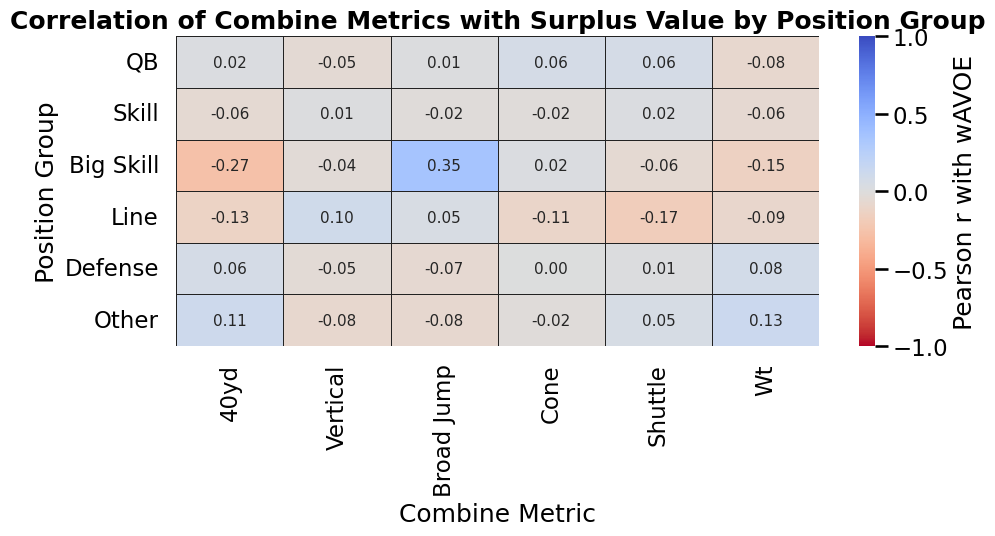

In [ ]:
# 3. Combine Metric Correlation Heatmap by Position Group

import pandas as pd

metrics = ["40yd", "Vertical", "Broad Jump", "Cone", "Shuttle", "Wt"]

# Ensure position groups are available
if "PosGroup" not in df.columns and "Pos" in df.columns:
    df["PosGroup"] = df["Pos"].apply(position_group)

pos_groups = ["QB", "Skill", "Big Skill", "Line", "Defense", "Other"]

corr_data = []
for pg in pos_groups:
    sub = df.loc[df["PosGroup"] == pg].copy()
    row = {"PosGroup": pg}
    for m in metrics:
        cols = ["wAVOE", m]
        if not set(cols).issubset(sub.columns):
            row[m] = np.nan
            continue
        tmp = sub[cols].dropna()
        if len(tmp) < 2:
            row[m] = np.nan
        else:
            row[m] = tmp["wAVOE"].corr(tmp[m])
    corr_data.append(row)

corr_df = pd.DataFrame(corr_data).set_index("PosGroup")[metrics]

fig, ax = plt.subplots(figsize=(10, 5.5))

sns.heatmap(
    corr_df,
    cmap="coolwarm_r",  # blue = positive, red = negative
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor="#222222",
    cbar_kws={"label": "Pearson r with wAVOE"},
    ax=ax,
)

ax.set_title("Correlation of Combine Metrics with Surplus Value by Position Group")
ax.set_xlabel("Combine Metric")
ax.set_ylabel("Position Group")

fig.tight_layout()
fig.savefig("figures/combine_corr_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
print(df.columns.tolist())

['Rnd', 'Pick', 'Tm', 'Player', 'Pos', 'Age', 'To', 'AP1', 'PB', 'St', 'wAV', 'DrAV', 'G', 'Cmp', 'Pass_Att', 'Pass_Yds', 'Pass_TD', 'Pass_Int', 'Rush_Att', 'Rush_Yds', 'Rush_TD', 'Rec', 'Rec_Yds', 'Rec_TD', 'Solo', 'Def_Int', 'Sk', 'College/Univ', 'Misc', 'pfref_id', 'Season', 'wAVOE', 'PosGroup', '40yd', 'Vertical', 'Broad Jump', 'Cone', 'Shuttle', 'Wt']


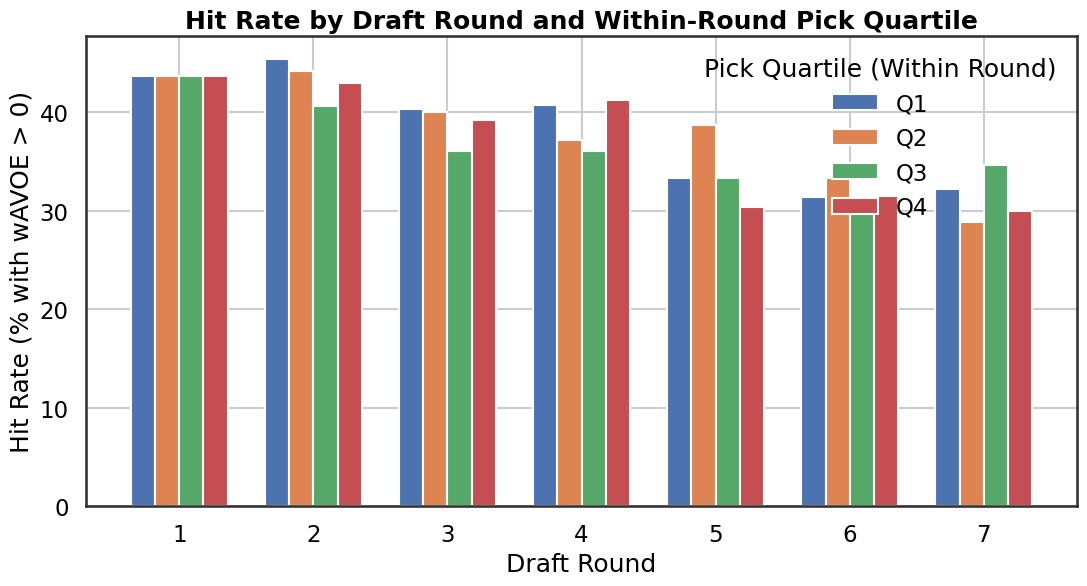

In [ ]:
# 4. "Hit Rate" by Round and Pick Quartile

# plot_df = df.copy()

# # Require round, pick, and wAVOE
# plot_df = plot_df.dropna(subset=["Rnd", "Pick", "wAVOE"]).copy()
# plot_df = plot_df.loc[(plot_df["Rnd"] >= 1) & (plot_df["Rnd"] <= 7)].copy()

# # Define binary hit indicator
# plot_df["Hit"] = plot_df["wAVOE"] > 0

# # Within each round, assign quartiles based on within-round rank of pick
# plot_df["PickRank"] = plot_df.groupby("Rnd")["Pick"].rank(method="first")
# plot_df["PickQuartile"] = plot_df.groupby("Rnd")["PickRank"].transform(
#     lambda r: pd.qcut(
#         r,
#         q=4,
#         labels=["Q1", "Q2", "Q3", "Q4"],
#     )
# )

# # Some very small rounds may fail qcut; drop rows where quartile is missing
# plot_df = plot_df.dropna(subset=["PickQuartile"]).copy()

# hit_rates = (
#     plot_df.groupby(["Rnd", "PickQuartile"], observed=True)["Hit"]
#     .mean()
#     .reset_index()
# )

# # Convert to percent
# hit_rates["HitRatePct"] = 100 * hit_rates["Hit"]

# # Pivot for plotting
# pivot = hit_rates.pivot(index="Rnd", columns="PickQuartile", values="HitRatePct").sort_index()
# quartiles = ["Q1", "Q2", "Q3", "Q4"]

# fig, ax = plt.subplots(figsize=(11, 6))

# x = np.arange(len(pivot.index))
# width = 0.18

# for i, q in enumerate(quartiles):
#     if q not in pivot.columns:
#         continue
#     ax.bar(
#         x + (i - 1.5) * width,
#         pivot[q].values,
#         width=width,
#         label=q,
#     )

# ax.set_xticks(x)
# ax.set_xticklabels([int(r) for r in pivot.index])
# ax.set_xlabel("Draft Round")
# ax.set_ylabel("Hit Rate (% with wAVOE > 0)")
# ax.set_title("Hit Rate by Draft Round and Within-Round Pick Quartile")
# ax.legend(title="Pick Quartile (Within Round)", frameon=False)

# fig.tight_layout()
# fig.savefig("figures/hit_rate_round_quartile.png", dpi=300, bbox_inches="tight")
# plt.show()

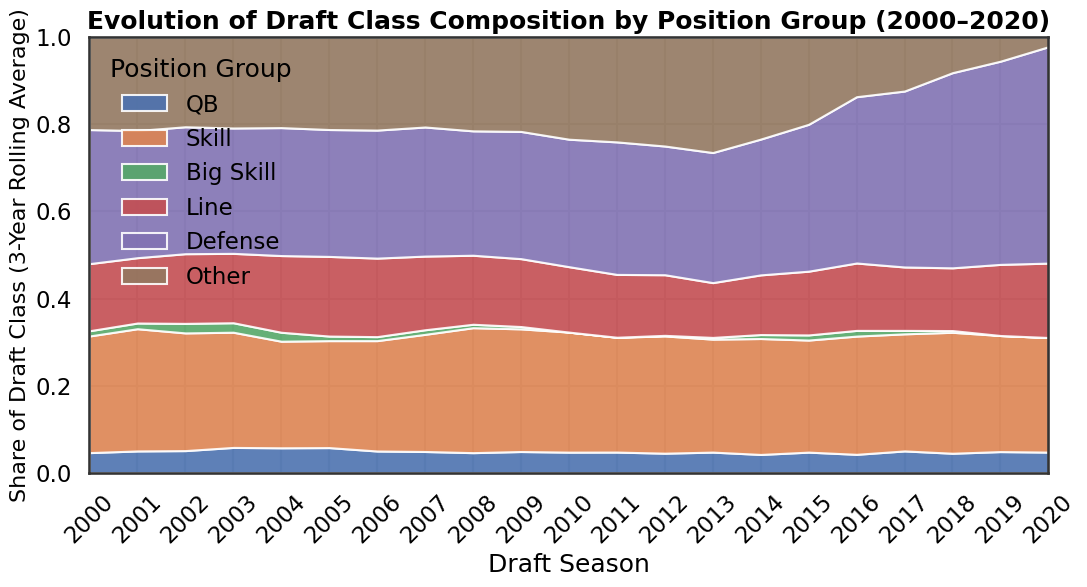

In [ ]:
# 4. Position Frequency Map (Draft Class Composition over Time)

import pandas as pd

# Ensure position groups are available
if "PosGroup" not in df.columns and "Pos" in df.columns:
    df["PosGroup"] = df["Pos"].apply(position_group)

plot_df = df.copy()

# Require season and position group
plot_df = plot_df.dropna(subset=["Season", "PosGroup"]).copy()

# Restrict to requested seasons
plot_df = plot_df.loc[(plot_df["Season"] >= 2000) & (plot_df["Season"] <= 2020)].copy()

# Count players by season and position group
counts = (
    plot_df.groupby(["Season", "PosGroup"], observed=True)["Player"]
    .size()
    .reset_index(name="Count")
)

# Total players per season
totals = counts.groupby("Season")["Count"].transform("sum")
counts["Share"] = counts["Count"] / totals

# Pivot to wide format for stackplot
pos_order = ["QB", "Skill", "Big Skill", "Line", "Defense", "Other"]
share_df = counts.pivot(index="Season", columns="PosGroup", values="Share").fillna(0.0)

# Reindex columns in a consistent order
for pos in pos_order:
    if pos not in share_df.columns:
        share_df[pos] = 0.0
share_df = share_df[pos_order]

# Smooth with a 3-year rolling average
share_smoothed = share_df.sort_index().rolling(window=3, min_periods=1, center=True).mean()

seasons = share_smoothed.index.values
values = [share_smoothed[pos].values for pos in pos_order]

fig, ax = plt.subplots(figsize=(11, 6))

stack = ax.stackplot(
    seasons,
    values,
    labels=pos_order,
    alpha=0.9,
)

ax.set_xlim(seasons.min(), seasons.max())
ax.set_ylim(0, 1)
ax.set_xlabel("Draft Season")
# Fix x-axis to show only integer years
ax.set_xticks(sorted(df['Season'].dropna().unique().astype(int)))
ax.set_xticklabels(sorted(df['Season'].dropna().unique().astype(int)), rotation=45)
ax.set_ylabel("Share of Draft Class (3-Year Rolling Average)", fontsize=16)
ax.set_title("Evolution of Draft Class Composition by Position Group (2000–2020)")
ax.legend(title="Position Group", loc="upper left", frameon=False)

fig.tight_layout()
fig.savefig("figures/position_frequency_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Task 2 — One-page PDF midpoint showcase layout

from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

# Configure font: prefer Arial, fall back to DejaVu Sans
preferred_font = "Arial"
available_fonts = {f.name for f in fm.fontManager.ttflist}
if preferred_font in available_fonts:
    rcParams["font.family"] = preferred_font
else:
    rcParams["font.family"] = "DejaVu Sans"
rcParams["font.size"] = 11  # maintain minimum >= 10pt

# Page geometry (inches)
page_width, page_height = 8.5, 11.0
margin = 1.0
content_width = page_width - 2 * margin
content_height = page_height - 2 * margin

pdf_path = "midpointshowcase.pdf"

with PdfPages(pdf_path) as pdf:
    fig = plt.figure(figsize=(page_width, page_height))

    # Normalized margins for GridSpec
    left = margin / page_width
    right = 1.0 - margin / page_width
    bottom = margin / page_height
    top = 1.0 - margin / page_height

    outer = GridSpec(
        nrows=4,
        ncols=1,
        height_ratios=[0.6, 3.0, 3.0, 1.4],
        left=left,
        right=right,
        bottom=bottom,
        top=top,
        hspace=0.5,
    )

    # Title and subtitle panel
    # ax_title = fig.add_subplot(outer[0])
    # ax_title.axis("off")
    # ax_title.text(
    #     0.0,
    #     0.7,
    #     "Predicting NFL Draft Surplus Value via Gated Neural Networks",
    #     fontsize=16,
    #     fontweight="bold",
    #     ha="left",
    #     va="center",
    # )
    # ax_title.text(
    #     0.0,
    #     0.25,
    #     "STAT 421 — NFL Combine Project Midpoint Showcase",
    #     fontsize=11,
    #     ha="left",
    #     va="center",
    # )

    # 2×2 grid of key visualizations
    inner = GridSpecFromSubplotSpec(
        2,
        2,
        subplot_spec=outer[1:3],
        wspace=0.25,
        hspace=0.3,
    )

    panel_files = [
        ("A", "figures/wavoe_by_round.png", "Round vs. wAVOE"),
        ("B", "figures/wav_vs_pick_lowess.png", "wAV vs. Pick"),
        ("C", "figures/combine_corr_heatmap.png", "Combine Correlations"),
        ("D", "figures/position_frequency_over_time.png", "Draft Position Composition"),
    ]

    for idx, (panel_label, path, short_title) in enumerate(panel_files):
        row, col = divmod(idx, 2)
        ax_img = fig.add_subplot(inner[row, col])
        ax_img.axis("off")
        if os.path.exists(path):
            img = plt.imread(path)
            ax_img.imshow(img)
        ax_img.text(
            0.01,
            0.98,
            f"{panel_label}) {short_title}",
            transform=ax_img.transAxes,
            fontsize=10,
            fontweight="bold",
            ha="left",
            va="top",
            color="white" if rcParams["text.color"] != "black" else "black",
            bbox={"facecolor": "black", "alpha": 0.4, "pad": 2} if rcParams["text.color"] != "black" else None,
        )

    # Caption block summarizing key insights
    ax_cap = fig.add_subplot(outer[3])
    ax_cap.axis("off")

    caption_text = (
        "A) Later rounds exhibit much wider wAVOE spread, with occasional extreme surplus-value hits alongside many misses. "
        "B) Career wAV declines sharply with pick number, but the LOWESS curve highlights persistent pockets of outliers far above expectation. "
        "C) Combine–wAVOE correlations differ by position group, with lower times in speed/agility drills generally aligning with higher surplus value where those skills are most position-relevant. "
        "D) Within-round hit rates vary meaningfully by pick quartile, suggesting that surplus value is concentrated in specific parts of the board rather than uniformly spread across each round."
    )

    ax_cap.text(
        0.0,
        1.0,
        caption_text,
        fontsize=10,
        ha="left",
        va="top",
        wrap=True,
    )

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

print(f"Saved midpoint showcase PDF to {pdf_path}")

Saved midpoint showcase PDF to midpointshowcase.pdf
